In [227]:
import numpy as np
import matplotlib.pylab as plt
from ioMicro import *

In [188]:
#D108 - day15 DKO
#D110 - day15 WT
#D118 - day0 WT

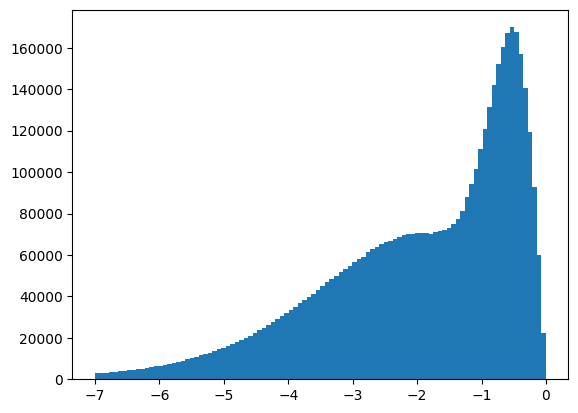

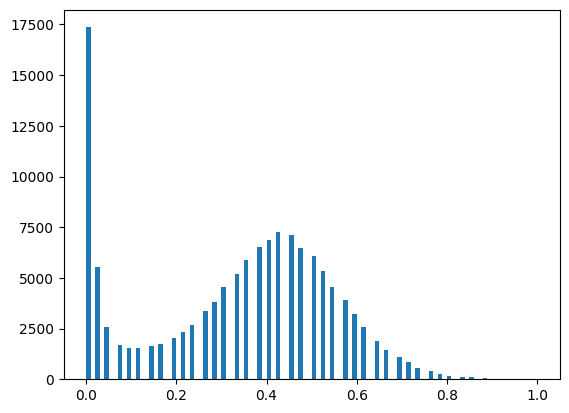

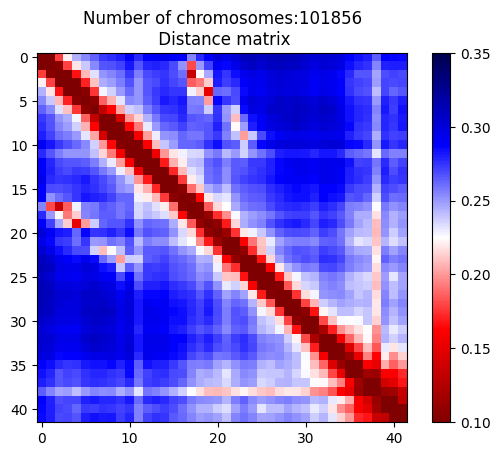

In [22]:
dic = np.load(r"C:\Users\Carlos\Desktop\Myh67_scripts\D118_traces_info.npz")#,zxys_fs=zxys_fs,score=score,icells_CMS=icells_CMS,th67=[th6,th7])
zxys_fs = dic['zxys_fs']
score = dic['score']
#icells_CMS = dic['icells_CMS']
icells = zxys_fs[:,0,-3]
score_ = score[~np.isnan(score)]
score_=score_[score_>-7]
plt.figure()
plt.hist(score_,bins=100);

X = zxys_fs[:,:,:3].copy()
X[score<-1.]=np.nan
fr = np.mean(~np.isnan(X[:,:,0]),axis=-1)
plt.figure()
plt.hist(fr,bins=100);
keep = (fr>0.1)#&np.in1d(icells,icells_CMS)
from scipy.spatial.distance import pdist,squareform
mats = np.array([squareform(pdist(X_)) for X_ in X[keep]])
mats_D118 = mats
plt.figure()
plt.title("Number of chromosomes:"+str(len(mats))+'\n Distance matrix')
plt.imshow(np.nanmedian(mats,axis=0),cmap='seismic_r',vmin=0.1,vmax=0.35)
plt.colorbar()

In [228]:
zxys_fs[:,0,-4]

array([7.0000000e+00, 8.0000000e+00, 1.3000000e+01, ..., 2.7900576e+07,
       2.7900579e+07, 2.7900583e+07])

C:\Users\carlos\AppData\Local\Temp\ipykernel_28176\3033158649.py:26: RuntimeWarning: divide by zero encountered in log
  H7,H6 = np.log(zxys_fs[keep,0,-2]),np.log(zxys_fs[keep,0,-3])
C:\Users\carlos\AppData\Local\Temp\ipykernel_28176\3033158649.py:40: RuntimeWarning: All-NaN slice encountered
  plt.imshow(np.nanmedian(mats_D120[keep6],axis=0),cmap='seismic_r',vmin=0.1,vmax=0.35)


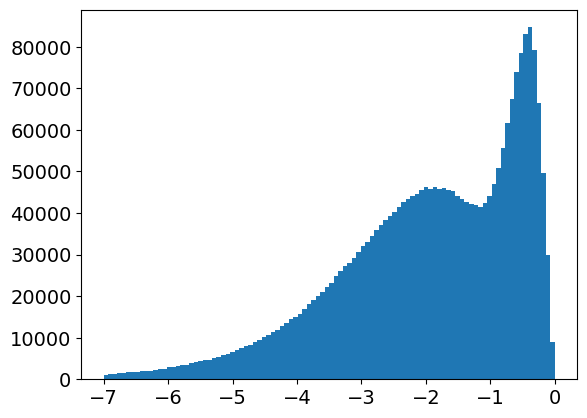

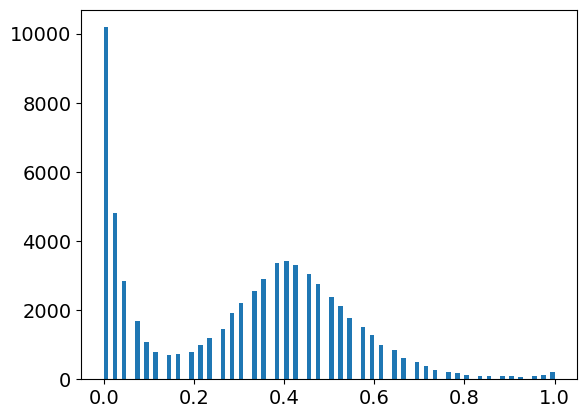

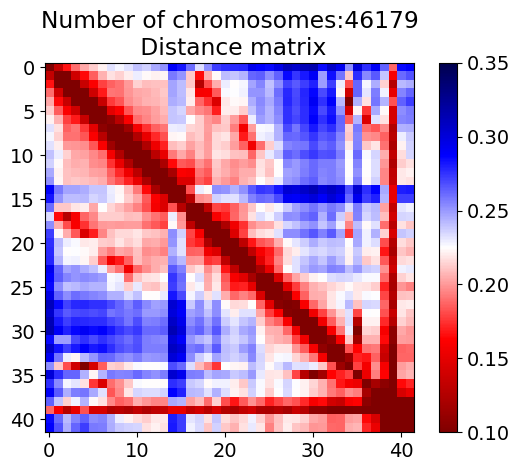

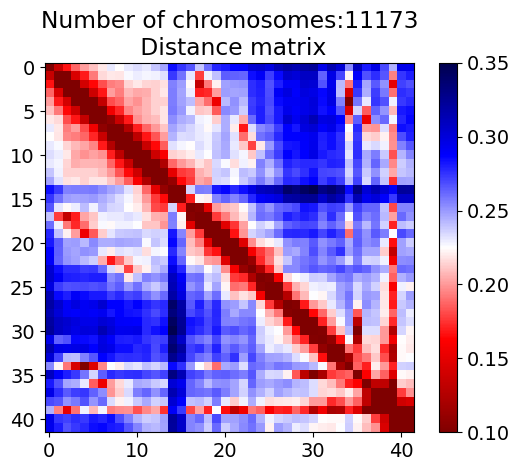

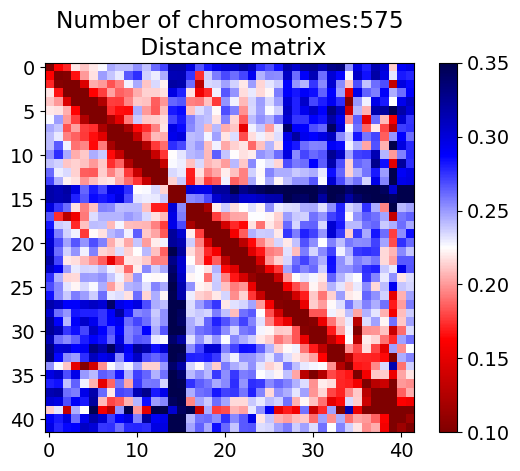

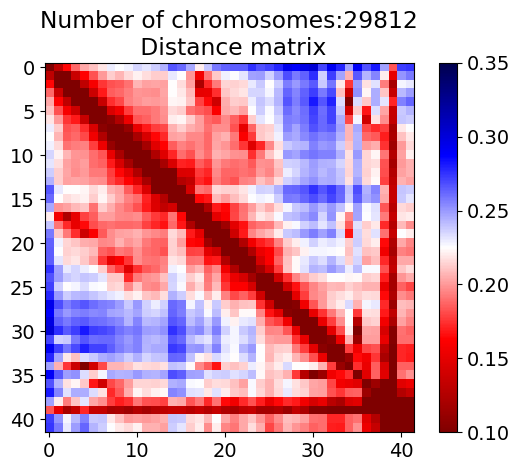

In [204]:
dic = np.load(r"C:\Users\Carlos\Desktop\Myh67_scripts\D114_traces_info.npz")#,zxys_fs=zxys_fs,score=score,icells_CMS=icells_CMS,th67=[th6,th7])
zxys_fs = dic['zxys_fs']
score = dic['score']
#icells_CMS = dic['icells_CMS']
icells = zxys_fs[:,0,-4]
score_ = score[~np.isnan(score)]
score_=score_[score_>-7]
th6, th7 = dic['th67']
plt.figure()
plt.hist(score_,bins=100);

X = zxys_fs[:,:,:3].copy()
X[score<-1.]=np.nan
fr = np.mean(~np.isnan(X[:,:,0]),axis=-1)
plt.figure()
plt.hist(fr,bins=100);
keep = (fr>0.1)#&np.in1d(icells,icells_CMS)
from scipy.spatial.distance import pdist,squareform
mats = np.array([squareform(pdist(X_)) for X_ in X[keep]])
mats_D120 = mats
plt.figure()
plt.title("Number of chromosomes:"+str(len(mats))+'\n Distance matrix')
plt.imshow(np.nanmedian(mats,axis=0),cmap='seismic_r',vmin=0.1,vmax=0.35)
plt.colorbar()

H7,H6 = np.log(zxys_fs[keep,0,-2]),np.log(zxys_fs[keep,0,-3])
# th7,th6 =10.5, 11
keep7 = (H7>th7)&(H6<th6)
keep6 = (H6>th6)&(H7<th7)
keepN = (H6<th6)&(H7<th7)

plt.figure()
plt.title("Number of chromosomes:"+str(len(mats[keep7]))+'\n Distance matrix')
plt.imshow(np.nanmedian(mats_D120[keep7],axis=0),cmap='seismic_r',vmin=0.1,vmax=0.35)
plt.colorbar()


plt.figure()
plt.title("Number of chromosomes:"+str(len(mats[keep6]))+'\n Distance matrix')
plt.imshow(np.nanmedian(mats_D120[keep6],axis=0),cmap='seismic_r',vmin=0.1,vmax=0.35)
plt.colorbar()

plt.figure()
plt.title("Number of chromosomes:"+str(len(mats[keepN]))+'\n Distance matrix')
plt.imshow(np.nanmedian(mats_D120[keepN],axis=0),cmap='seismic_r',vmin=0.1,vmax=0.35)
plt.colorbar()

C:\Users\carlos\AppData\Local\Temp\ipykernel_28176\1573423138.py:35: RuntimeWarning: All-NaN slice encountered
  plt.imshow(np.nanmedian(mats_D120_myl2_h6, axis=0), cmap='seismic_r', vmin=0.1, vmax=0.35)


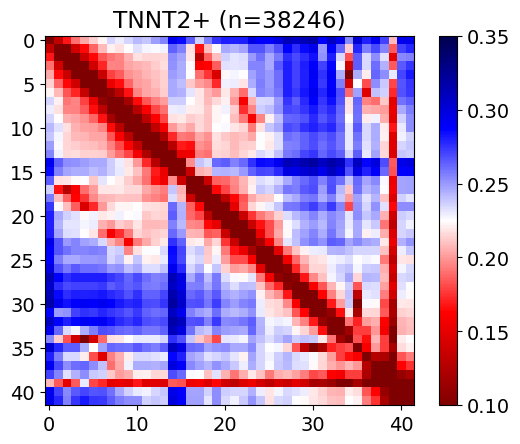

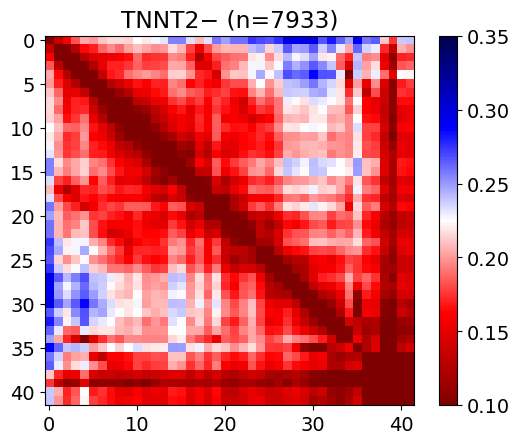

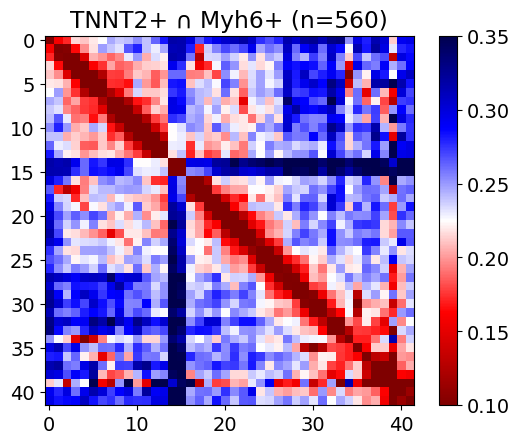

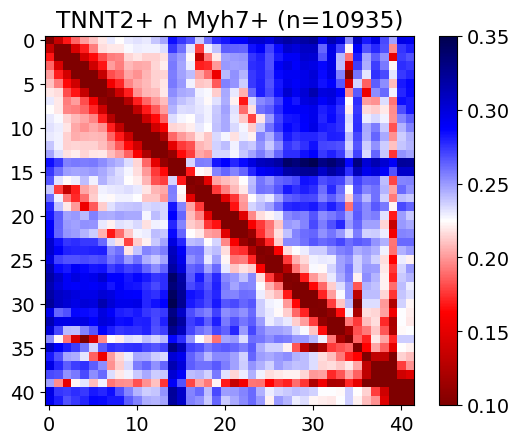

In [205]:
# Step 1: Get MYL2+ mask (assuming flag stored at last position)
is_MYL2 = zxys_fs[keep, 0, -1] == 1
is_not_MYL2 = zxys_fs[keep, 0, -1] == 0

# Step 2: Use already-defined H6, H7 and keep masks
# H6, H7 already defined as log intensities
is_H6_pos = H6 > th6
is_H7_pos = H7 > th7

# Step 3: Define combinations
keep_myl2 = is_MYL2
keep_nonmyl2 = is_not_MYL2
keep_myl2_myh6 = is_MYL2 & is_H6_pos & ~is_H7_pos
keep_myl2_myh7 = is_MYL2 & is_H7_pos & ~is_H6_pos

# Step 4: Compute matrices
mats_D120_myl2     = mats_D120[keep_myl2]
mats_D120_nonmyl2  = mats_D120[keep_nonmyl2]
mats_D120_myl2_h6  = mats_D120[keep_myl2_myh6]
mats_D120_myl2_h7  = mats_D120[keep_myl2_myh7]

# Step 5: Plot
plt.figure()
plt.title(f"TNNT2+ (n={len(mats_D120_myl2)})")
plt.imshow(np.nanmedian(mats_D120_myl2, axis=0), cmap='seismic_r', vmin=0.1, vmax=0.35)
plt.colorbar()

plt.figure()
plt.title(f"TNNT2− (n={len(mats_D120_nonmyl2)})")
plt.imshow(np.nanmedian(mats_D120_nonmyl2, axis=0), cmap='seismic_r', vmin=0.1, vmax=0.35)
plt.colorbar()

plt.figure()
plt.title(f"TNNT2+ ∩ Myh6+ (n={len(mats_D120_myl2_h6)})")
plt.imshow(np.nanmedian(mats_D120_myl2_h6, axis=0), cmap='seismic_r', vmin=0.1, vmax=0.35)
plt.colorbar()

plt.figure()
plt.title(f"TNNT2+ ∩ Myh7+ (n={len(mats_D120_myl2_h7)})")
plt.imshow(np.nanmedian(mats_D120_myl2_h7, axis=0), cmap='seismic_r', vmin=0.1, vmax=0.35)
plt.colorbar()

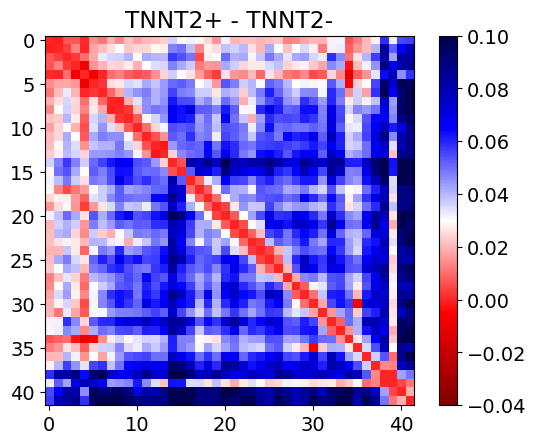

In [206]:
plt.figure()
plt.title(f"TNNT2+ - TNNT2-")
plt.imshow(np.nanmedian(mats_D120_myl2, axis=0)-np.nanmedian(mats_D120_nonmyl2, axis=0), cmap='seismic_r', vmin=-0.04, vmax=0.1)
plt.colorbar()

C:\Users\carlos\AppData\Local\Temp\ipykernel_28176\1873751004.py:26: RuntimeWarning: divide by zero encountered in log
  H7,H6 = np.log(zxys_fs[keep,0,-2]),np.log(zxys_fs[keep,0,-3])
C:\Users\carlos\anaconda3\envs\cellpose2\lib\site-packages\numpy\lib\nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,


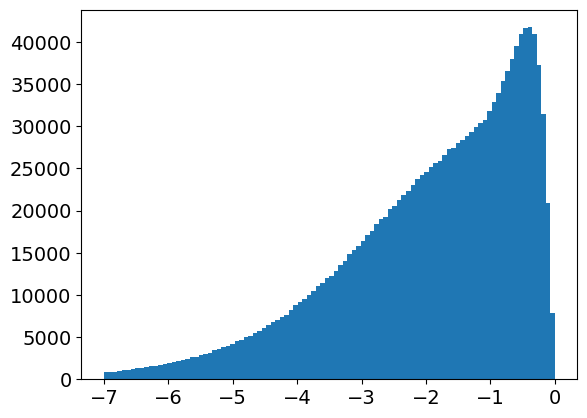

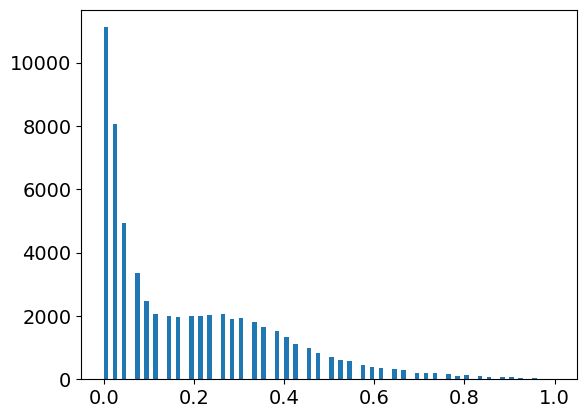

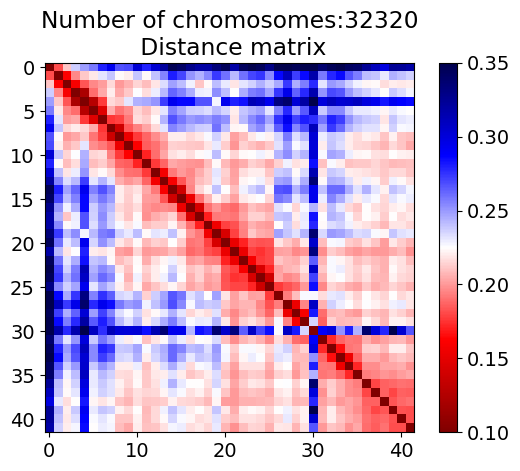

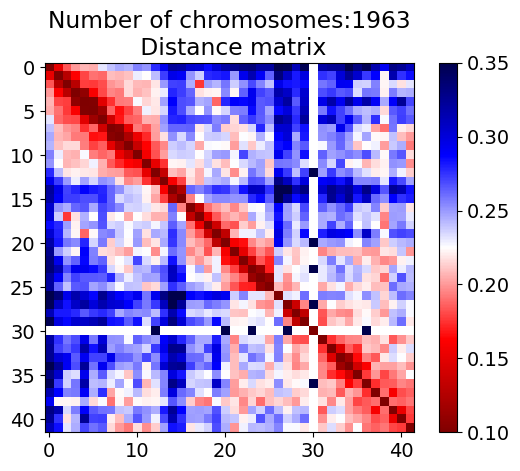

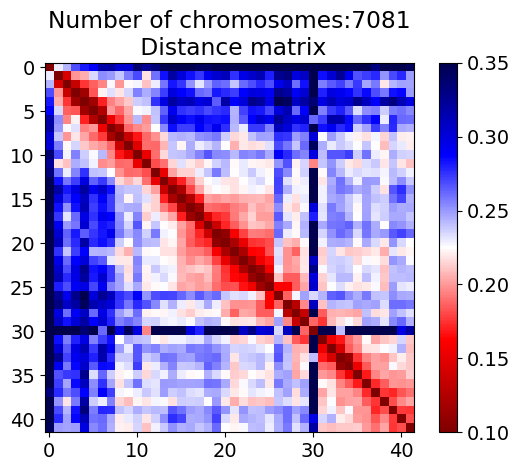

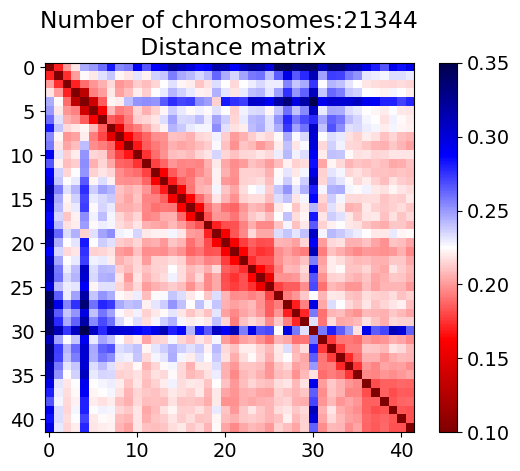

In [207]:
dic = np.load(r"C:\Users\Carlos\Desktop\Myh67_scripts\D110_traces_info.npz")#,zxys_fs=zxys_fs,score=score,icells_CMS=icells_CMS,th67=[th6,th7])
zxys_fs = dic['zxys_fs']
score = dic['score']
#icells_CMS = dic['icells_CMS']
icells = zxys_fs[:,0,-4]
score_ = score[~np.isnan(score)]
score_=score_[score_>-7]
th6, th7 = dic['th67']
plt.figure()
plt.hist(score_,bins=100);

X = zxys_fs[:,:,:3].copy()
X[score<-1.]=np.nan
fr = np.mean(~np.isnan(X[:,:,0]),axis=-1)
plt.figure()
plt.hist(fr,bins=100);
keep = (fr>0.1)#&np.in1d(icells,icells_CMS)
from scipy.spatial.distance import pdist,squareform
mats = np.array([squareform(pdist(X_)) for X_ in X[keep]])
mats_D104 = mats
plt.figure()
plt.title("Number of chromosomes:"+str(len(mats))+'\n Distance matrix')
plt.imshow(np.nanmedian(mats,axis=0),cmap='seismic_r',vmin=0.1,vmax=0.35)
plt.colorbar()

H7,H6 = np.log(zxys_fs[keep,0,-2]),np.log(zxys_fs[keep,0,-3])
# th7,th6 =10.5, 11
keep7 = (H7>th7)&(H6<th6)
keep6 = (H6>th6)&(H7<th7)
keepN = (H6<th6)&(H7<th7)

plt.figure()
plt.title("Number of chromosomes:"+str(len(mats[keep7]))+'\n Distance matrix')
plt.imshow(np.nanmedian(mats_D104[keep7],axis=0),cmap='seismic_r',vmin=0.1,vmax=0.35)
plt.colorbar()


plt.figure()
plt.title("Number of chromosomes:"+str(len(mats[keep6]))+'\n Distance matrix')
plt.imshow(np.nanmedian(mats_D104[keep6],axis=0),cmap='seismic_r',vmin=0.1,vmax=0.35)
plt.colorbar()

plt.figure()
plt.title("Number of chromosomes:"+str(len(mats[keepN]))+'\n Distance matrix')
plt.imshow(np.nanmedian(mats_D104[keepN],axis=0),cmap='seismic_r',vmin=0.1,vmax=0.35)
plt.colorbar()

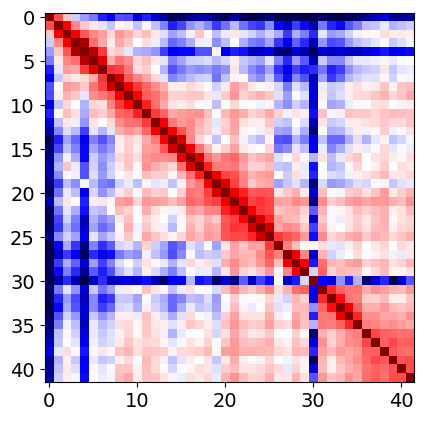

In [208]:
D15mat = np.nanmedian(mats,axis=0)

plt.figure()
plt.imshow(D15mat,cmap='seismic_r',vmin=0.1,vmax=0.35)
plt.savefig(fr"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\D15WT_distance.pdf", format='pdf', bbox_inches='tight', dpi=600)

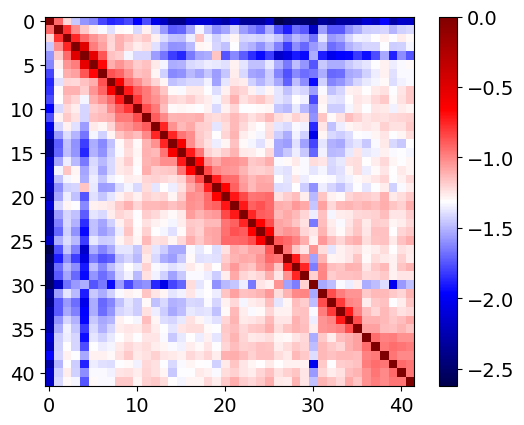

In [209]:
dth = 0.15
D15mat_contact = np.sum(mats<dth,axis=0)/np.sum(mats>=0,axis=0)
plt.figure()
plt.imshow(np.log(D15mat_contact),cmap='seismic')
plt.colorbar()
plt.savefig(fr"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\D15WT_contact.pdf", format='pdf', bbox_inches='tight', dpi=600)

In [210]:
np.save(r"C:\Users\carlos\Desktop\Myh67_scripts\HiC_Compare\D15matrix.npy", D15mat)
np.save(r"C:\Users\carlos\Desktop\Myh67_scripts\HiC_Compare\D15matrix_contact.npy", D15mat_contact)

C:\Users\carlos\anaconda3\envs\cellpose2\lib\site-packages\numpy\lib\nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,


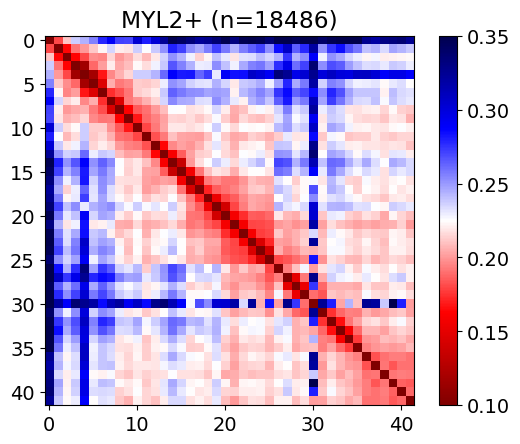

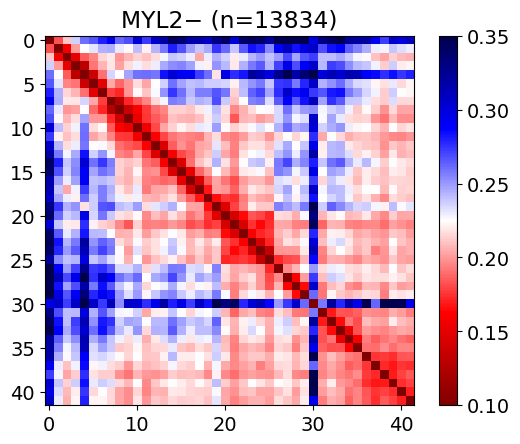

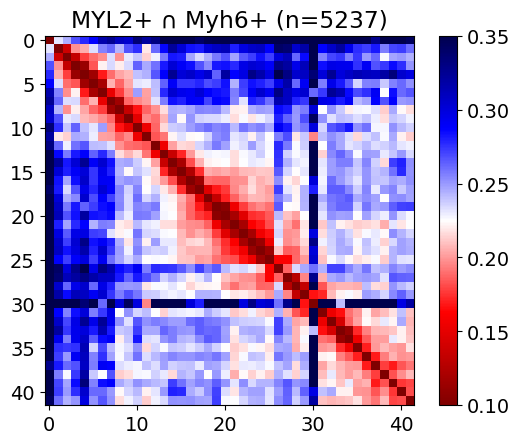

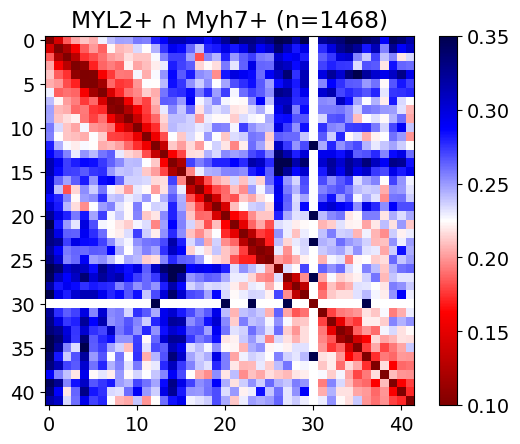

In [211]:
# Step 1: Get MYL2+ mask (assuming flag stored at last position)
is_MYL2 = zxys_fs[keep, 0, -1] == 1
is_not_MYL2 = zxys_fs[keep, 0, -1] == 0

# Step 2: Use already-defined H6, H7 and keep masks
# H6, H7 already defined as log intensities
is_H6_pos = H6 > th6
is_H7_pos = H7 > th7

# Step 3: Define combinations
keep_myl2 = is_MYL2
keep_nonmyl2 = is_not_MYL2
keep_myl2_myh6 = is_MYL2 & is_H6_pos & ~is_H7_pos
keep_myl2_myh7 = is_MYL2 & is_H7_pos & ~is_H6_pos

# Step 4: Compute matrices
mats_D104_myl2     = mats_D104[keep_myl2]
mats_D104_nonmyl2  = mats_D104[keep_nonmyl2]
mats_D104_myl2_h6  = mats_D104[keep_myl2_myh6]
mats_D104_myl2_h7  = mats_D104[keep_myl2_myh7]

# Step 5: Plot
plt.figure()
plt.title(f"MYL2+ (n={len(mats_D104_myl2)})")
plt.imshow(np.nanmedian(mats_D104_myl2, axis=0), cmap='seismic_r', vmin=0.1, vmax=0.35)
plt.colorbar()

plt.figure()
plt.title(f"MYL2− (n={len(mats_D104_nonmyl2)})")
plt.imshow(np.nanmedian(mats_D104_nonmyl2, axis=0), cmap='seismic_r', vmin=0.1, vmax=0.35)
plt.colorbar()

plt.figure()
plt.title(f"MYL2+ ∩ Myh6+ (n={len(mats_D104_myl2_h6)})")
plt.imshow(np.nanmedian(mats_D104_myl2_h6, axis=0), cmap='seismic_r', vmin=0.1, vmax=0.35)
plt.colorbar()

plt.figure()
plt.title(f"MYL2+ ∩ Myh7+ (n={len(mats_D104_myl2_h7)})")
plt.imshow(np.nanmedian(mats_D104_myl2_h7, axis=0), cmap='seismic_r', vmin=0.1, vmax=0.35)
plt.colorbar()

In [10]:
med_D120 = np.nanmedian(mats_D120,axis=0)
med_D118 = np.nanmedian(mats_D118,axis=0)
med_D104 = np.nanmedian(mats_D104, axis=0)

In [59]:
i1,i2 = [13,28]
med_D104[i1, i2], med_D120[i1, i2]

(0.23085404636396126, 0.2529074813113614)

In [64]:
i1,i2 = [13,31]
med_D104[i1, i2], med_D120[i1, i2]

(0.2237637278707314, 0.25396666762706255)

In [65]:
i1,i2 = [27,31]
med_D104[i1, i2], med_D120[i1, i2]

(0.20601099188368455, 0.2031053554225468)

In [212]:
def get_random_maps(mats,iDNA7_,N=100,dth=0.1):
    med_7_Cs = []
    for i in tqdm(np.arange(N)):
        iRand = np.random.randint(0,len(iDNA7_),len(iDNA7_))
        med_7_C = np.mean(mats[iDNA7_[iRand]]<dth,axis=0)/np.mean(mats[iDNA7_[iRand]]>=0,axis=0)
        med_7_Cs.append(med_7_C)
    return np.array(med_7_Cs)

In [38]:
from tqdm import tqdm
# mats_D103_7 = get_random_maps(mats_D103,np.where(keep7)[0],N=100,dth=0.1)
# mats_D103_6 = get_random_maps(mats_D103,np.where(keep6)[0],N=100,dth=0.1)

mats_D120_p = get_random_maps(mats_D120_myl2,np.arange(len(mats_D120_myl2)),N=100,dth=0.1)
mats_D120_m = get_random_maps(mats_D120_nonmyl2,np.arange(len(mats_D120_nonmyl2)),N=100,dth=0.1)
mats_D104_p = get_random_maps(mats_D104_myl2,np.arange(len(mats_D104_myl2)),N=100,dth=0.1)
mats_D104_m = get_random_maps(mats_D104_nonmyl2,np.arange(len(mats_D104_nonmyl2)),N=100,dth=0.1)
mats_D118_all = get_random_maps(mats_D118,np.arange(len(mats_D118)),N=100,dth=0.1)

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [01:40<00:00,  1.00s/it]


In [213]:
from tqdm import tqdm

mats_D120_p = get_random_maps(mats_D120_myl2,np.arange(len(mats_D120_myl2)),N=100,dth=0.1)
mats_D104_p = get_random_maps(mats_D104_myl2,np.arange(len(mats_D104_myl2)),N=100,dth=0.1)

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:14<00:00,  6.68it/s]


In [214]:
mats_D120_all = get_random_maps(mats_D120,np.arange(len(mats_D120)),N=100,dth=0.1)
mats_D104_all = get_random_maps(mats_D104,np.arange(len(mats_D104)),N=100,dth=0.1)

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:25<00:00,  3.86it/s]


In [235]:
len(mats_D104_myl2), len(mats_D120_myl2)

(18486, 38246)

In [203]:
len(mats_D104_myl2), len(mats_D120_myl2)

(18486, 38246)

In [61]:
len(mats_D104), len(mats_D120)

(32320, 46179)

Rank-sum p-value between D15 6PKO and D15 WT: 1.16e-33


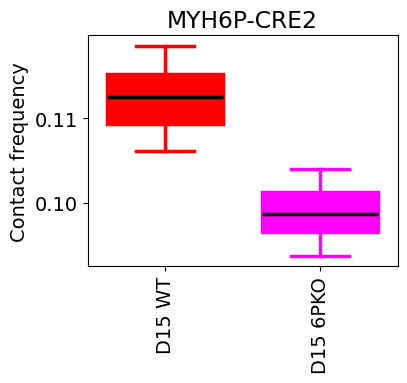

In [134]:
i1,i2 = [13,28]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ranksums

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_all[:,i1,i2]
box_X = ax.boxplot(X, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_all[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

# Rank-sum test
stat, pval = ranksums(X, Z)
print(f"Rank-sum p-value between D15 6PKO and D15 WT: {pval:.2e}")

plt.xlim([-0.1,0.3])
plt.xticks([0,0.2],['D15 WT','D15 6PKO'],rotation='vertical')
plt.title('MYH6P-CRE2')
plt.ylabel("Contact frequency")

plt.savefig(fr"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure4\Figure46PKO_{i1}_{i2}.pdf", format='pdf', bbox_inches='tight', dpi=600)

Rank-sum p-value between D15 6PKO and D15 WT: 2.52e-34


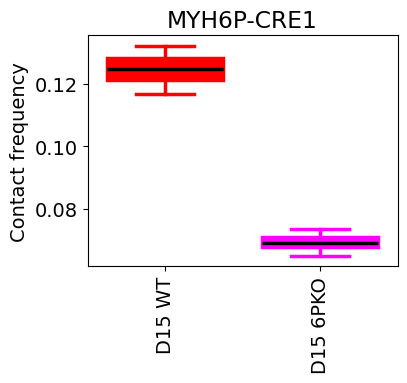

In [135]:
i1,i2 = [13,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_all[:,i1,i2]
box_X = ax.boxplot(X, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_all[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

# Rank-sum test
stat, pval = ranksums(X, Z)
print(f"Rank-sum p-value between D15 6PKO and D15 WT: {pval:.2e}")

plt.xlim([-0.1,0.3])
plt.xticks([0,0.2],['D15 WT','D15 6PKO'],rotation='vertical')
plt.title('MYH6P-CRE1')
plt.ylabel("Contact frequency")

plt.savefig(fr"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure4\Figure46PKO_{i1}_{i2}.pdf", format='pdf', bbox_inches='tight', dpi=600)

Rank-sum p-value between D15 6PKO and D15 WT: 3.41e-34


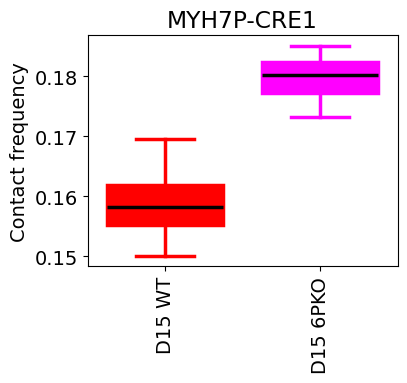

In [216]:
i1,i2 = [27,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_all[:,i1,i2]
box_X = ax.boxplot(X, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_all[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

# Rank-sum test
stat, pval = ranksums(X, Z)
print(f"Rank-sum p-value between D15 6PKO and D15 WT: {pval:.2e}")

plt.xlim([-0.1,0.3])
plt.xticks([0,0.2],['D15 WT','D15 6PKO'],rotation='vertical')
plt.title('MYH7P-CRE1')
plt.ylabel("Contact frequency")

plt.savefig(fr"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure4\Figure46PKO_{i1}_{i2}.pdf", format='pdf', bbox_inches='tight', dpi=600)

Rank-sum p-value between D15 6PKO and D15 WT: 2.52e-34


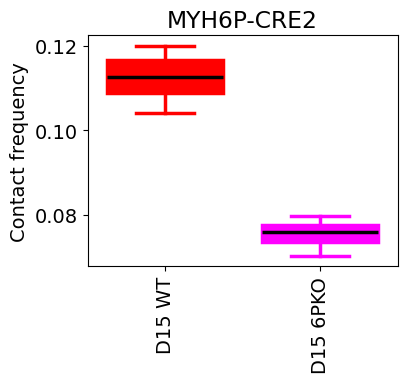

In [234]:
i1,i2 = [13,28]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ranksums

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_p[:,i1,i2]
box_X = ax.boxplot(X, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_p[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

# Rank-sum test
stat, pval = ranksums(X, Z)
print(f"Rank-sum p-value between D15 6PKO and D15 WT: {pval:.2e}")

plt.xlim([-0.1,0.3])
plt.xticks([0,0.2],['D15 WT','D15 6PKO'],rotation='vertical')
plt.title('MYH6P-CRE2')
plt.ylabel("Contact frequency")

plt.savefig(fr"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure4\Figure46PKO_{i1}_{i2}.pdf", format='pdf', bbox_inches='tight', dpi=600)

Rank-sum p-value between D15 6PKO and D15 WT: 2.52e-34


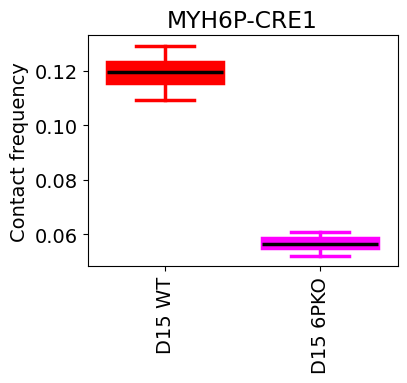

In [233]:
i1,i2 = [13,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_p[:,i1,i2]
box_X = ax.boxplot(X, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_p[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

# Rank-sum test
stat, pval = ranksums(X, Z)
print(f"Rank-sum p-value between D15 6PKO and D15 WT: {pval:.2e}")

plt.xlim([-0.1,0.3])
plt.xticks([0,0.2],['D15 WT','D15 6PKO'],rotation='vertical')
plt.title('MYH6P-CRE1')
plt.ylabel("Contact frequency")

plt.savefig(fr"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure4\Figure46PKO_{i1}_{i2}.pdf", format='pdf', bbox_inches='tight', dpi=600)

Rank-sum p-value between D15 6PKO and D15 WT: 5.21e-04


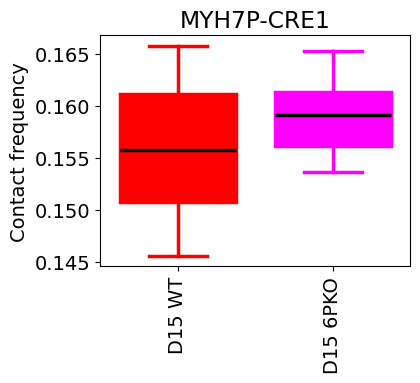

In [232]:
i1,i2 = [27,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_p[:,i1,i2]
box_X = ax.boxplot(X, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_p[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

# Rank-sum test
stat, pval = ranksums(X, Z)
print(f"Rank-sum p-value between D15 6PKO and D15 WT: {pval:.2e}")

plt.xlim([-0.1,0.3])
plt.xticks([0,0.2],['D15 WT','D15 6PKO'],rotation='vertical')
plt.title('MYH7P-CRE1')
plt.ylabel("Contact frequency")

plt.savefig(fr"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure4\Figure46PKO_{i1}_{i2}.pdf", format='pdf', bbox_inches='tight', dpi=600)

In [218]:
import numpy as np
from tqdm import tqdm

def get_random_med(mats, iDNA7_, N=100):
    med_7_Cs = []
    for i in tqdm(np.arange(N)):
        # sample with replacement
        iRand = np.random.randint(0, len(iDNA7_), len(iDNA7_))
        # take subset and compute nanmedian along axis=0
        med_7_C = np.nanmedian(mats[iDNA7_[iRand]], axis=0)
        med_7_Cs.append(med_7_C)
    return np.array(med_7_Cs)

In [219]:
mats_D120_med = get_random_med(mats_D120,np.arange(len(mats_D120)),N=100)
mats_D104_med = get_random_med(mats_D104,np.arange(len(mats_D104)),N=100)

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:54<00:00,  1.83it/s]


In [220]:
mats_D120_med_p = get_random_med(mats_D120_myl2,np.arange(len(mats_D120_myl2)),N=100)
mats_D104_med_p = get_random_med(mats_D104_myl2,np.arange(len(mats_D104_myl2)),N=100)

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:35<00:00,  2.83it/s]


Rank-sum p-value between D15 6PKO and D15 WT: 2.52e-34


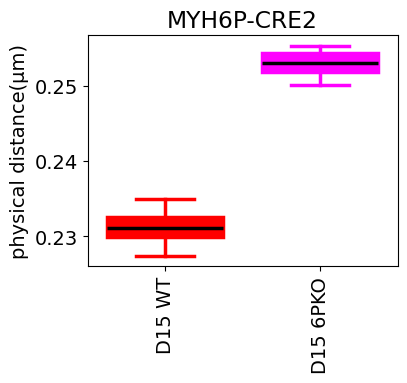

In [221]:
i1,i2 = [13,28]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ranksums

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_med[:,i1,i2]
box_X = ax.boxplot(X, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_med[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

# Rank-sum test
stat, pval = ranksums(X, Z)
print(f"Rank-sum p-value between D15 6PKO and D15 WT: {pval:.2e}")

plt.xlim([-0.1,0.3])
plt.xticks([0,0.2],['D15 WT','D15 6PKO'],rotation='vertical')
plt.title('MYH6P-CRE2')
plt.ylabel("physical distance(µm)")

plt.savefig(fr"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure4\Figure46PKO_{i1}_{i2}_dis.pdf", format='pdf', bbox_inches='tight', dpi=600)

Rank-sum p-value between D15 6PKO and D15 WT: 2.52e-34


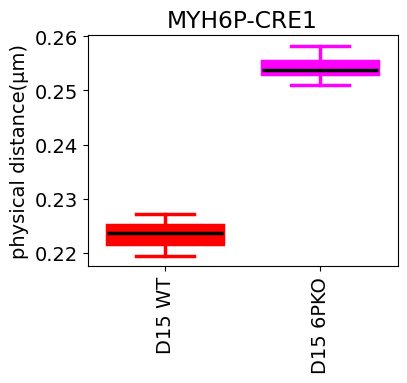

In [222]:
i1,i2 = [13,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ranksums

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_med[:,i1,i2]
box_X = ax.boxplot(X, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_med[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

# Rank-sum test
stat, pval = ranksums(X, Z)
print(f"Rank-sum p-value between D15 6PKO and D15 WT: {pval:.2e}")

plt.xlim([-0.1,0.3])
plt.xticks([0,0.2],['D15 WT','D15 6PKO'],rotation='vertical')
plt.title('MYH6P-CRE1')
plt.ylabel("physical distance(µm)")

plt.savefig(fr"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure4\Figure46PKO_{i1}_{i2}_dis.pdf", format='pdf', bbox_inches='tight', dpi=600)

Rank-sum p-value between D15 6PKO and D15 WT: 4.34e-13


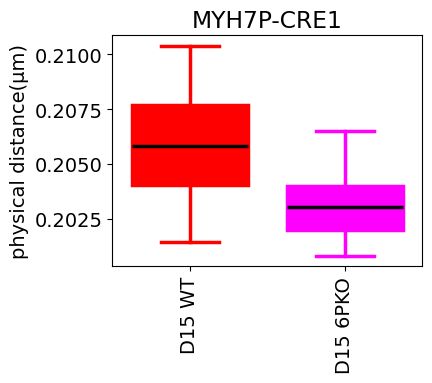

In [180]:
i1,i2 = [27,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ranksums

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_med[:,i1,i2]
box_X = ax.boxplot(X, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_med[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

# Rank-sum test
stat, pval = ranksums(X, Z)
print(f"Rank-sum p-value between D15 6PKO and D15 WT: {pval:.2e}")

plt.xlim([-0.1,0.3])
plt.xticks([0,0.2],['D15 WT','D15 6PKO'],rotation='vertical')
plt.title('MYH7P-CRE1')
plt.ylabel("physical distance(µm)")

plt.savefig(fr"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure4\Figure46PKO_{i1}_{i2}_dis.pdf", format='pdf', bbox_inches='tight', dpi=600)

Rank-sum p-value between D15 6PKO and D15 WT: 3.58e-24


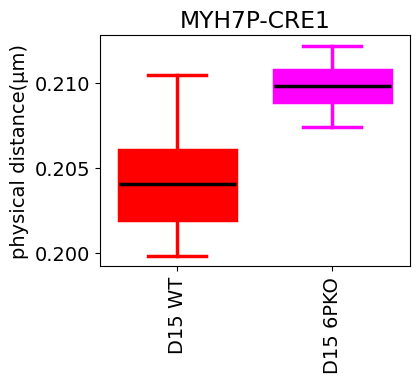

In [223]:
i1,i2 = [27,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ranksums

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_med_p[:,i1,i2]
box_X = ax.boxplot(X, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_med_p[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

# Rank-sum test
stat, pval = ranksums(X, Z)
print(f"Rank-sum p-value between D15 6PKO and D15 WT: {pval:.2e}")

plt.xlim([-0.1,0.3])
plt.xticks([0,0.2],['D15 WT','D15 6PKO'],rotation='vertical')
plt.title('MYH7P-CRE1')
plt.ylabel("physical distance(µm)")

plt.savefig(fr"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure46PKO_{i1}_{i2}_dis.pdf", format='pdf', bbox_inches='tight', dpi=600)

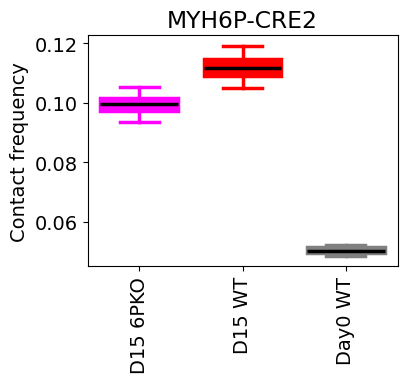

In [20]:
i1,i2 = [13,28]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_all[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_all[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

W = mats_D118_all[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='gray', color='gray',linewidth=line_width),
                   whiskerprops=dict(color='gray',linewidth=line_width),
                   capprops=dict(color='gray',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.5])
plt.xticks([0,0.2,0.4],['D15 6PKO','D15 WT','Day0 WT'],rotation='vertical')
plt.title('MYH6P-CRE2')
plt.ylabel("Contact frequency")

plt.savefig(fr"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure46PKO_{i1}_{i2}.jpg", format='jpg', bbox_inches='tight', dpi = 600)

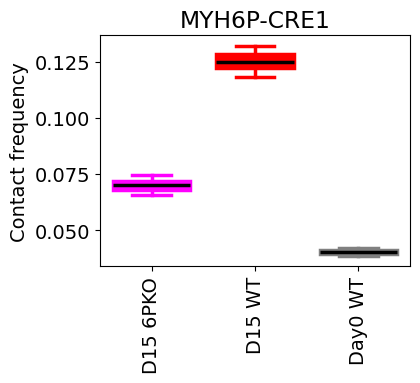

In [21]:
i1,i2 = [13,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_all[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_all[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

W = mats_D118_all[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='gray', color='gray',linewidth=line_width),
                   whiskerprops=dict(color='gray',linewidth=line_width),
                   capprops=dict(color='gray',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.5])
plt.xticks([0,0.2,0.4],['D15 6PKO','D15 WT','Day0 WT'],rotation='vertical')
plt.title('MYH6P-CRE1')
plt.ylabel("Contact frequency")

plt.savefig(fr"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure46PKO_{i1}_{i2}.jpg", format='jpg', bbox_inches='tight', dpi = 600)

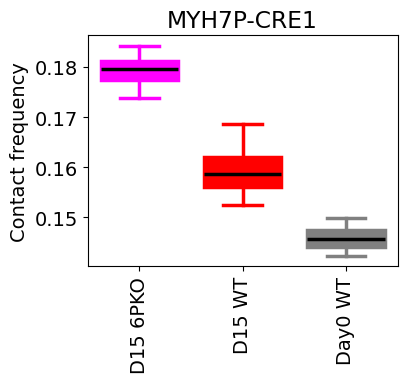

In [22]:
i1,i2 = [27,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))
# X = mats_D103_6[:,i1,i2]
# box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
#                    boxprops=dict(facecolor='red', color='red',linewidth=line_width),
#                    whiskerprops=dict(color='red',linewidth=line_width),
#                    capprops=dict(color='red',linewidth=line_width),
#                    medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

# # Box plot for Y in green
# Y = mats_D103_7[:,i1,i2]
# box_Y = ax.boxplot(Y, positions=[0.2], patch_artist=True, 
#                    boxprops=dict(facecolor='green', color='green',linewidth=line_width),
#                    whiskerprops=dict(color='green',linewidth=line_width),
#                    capprops=dict(color='green',linewidth=line_width),
#                    medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

X = mats_D120_all[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_all[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)


W = mats_D118_all[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='gray', color='gray',linewidth=line_width),
                   whiskerprops=dict(color='gray',linewidth=line_width),
                   capprops=dict(color='gray',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.5])
plt.xticks([0,0.2,0.4],['D15 6PKO','D15 WT','Day0 WT'],rotation='vertical')
plt.title('MYH7P-CRE1')
plt.ylabel("Contact frequency")

plt.savefig(fr"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure46PKO_{i1}_{i2}.jpg", format='jpg', bbox_inches='tight', dpi = 600)

Text(0, 0.5, 'Contact frequency')

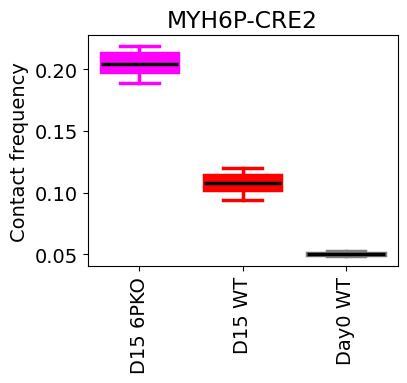

In [43]:
i1,i2 = [13,28]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_m[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_m[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

W = mats_D118_all[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='gray', color='gray',linewidth=line_width),
                   whiskerprops=dict(color='gray',linewidth=line_width),
                   capprops=dict(color='gray',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.5])
plt.xticks([0,0.2,0.4],['D15 6PKO','D15 WT','Day0 WT'],rotation='vertical')
plt.title('MYH6P-CRE2')
plt.ylabel("Contact frequency")

Text(0, 0.5, 'Contact frequency')

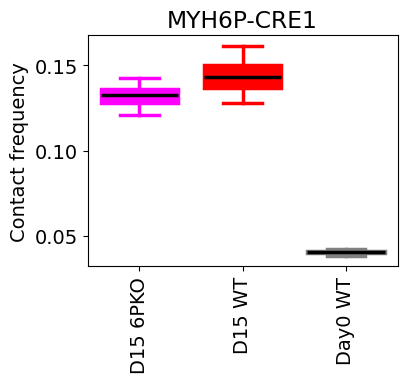

In [44]:
i1,i2 = [13,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_m[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_m[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

W = mats_D118_all[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='gray', color='gray',linewidth=line_width),
                   whiskerprops=dict(color='gray',linewidth=line_width),
                   capprops=dict(color='gray',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.5])
plt.xticks([0,0.2,0.4],['D15 6PKO','D15 WT','Day0 WT'],rotation='vertical')
plt.title('MYH6P-CRE1')
plt.ylabel("Contact frequency")

Text(0, 0.5, 'Contact frequency')

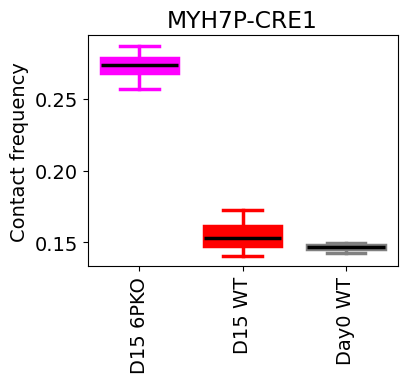

In [45]:
i1,i2 = [27,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_m[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_m[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

W = mats_D118_all[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='gray', color='gray',linewidth=line_width),
                   whiskerprops=dict(color='gray',linewidth=line_width),
                   capprops=dict(color='gray',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.5])
plt.xticks([0,0.2,0.4],['D15 6PKO','D15 WT','Day0 WT'],rotation='vertical')
plt.title('MYH7P-CRE1')
plt.ylabel("Contact frequency")